## Creating ReAct with multiple TOOLS

### What is TAVILY API
Tavily API is
an "LLM-native" search engine designed specifically for AI agents and Retrieval-Augmented Generation (RAG) applications

In [1]:
import os
from langchain_groq import ChatGroq

# NO need to import Groq API as in previous notebook we alsoready impoerted it and we are using the same kernel 
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
groq = ChatGroq(model_name="llama-3.1-8b-instant")

In [24]:
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(
    max_results=5,
    topic="finance"
)

# tavily_tool.invoke("How is AI market affected by Middle East War?")


In [25]:
from langchain.tools import tool

@tool("Calculator",description="Use this tool to perform basic arithematic calculations like addition, subtraction, multiplication, division.")
def calculator(expression: str) -> str:
    """Evaluate basic Arithematic operations"""
    return str(eval(expression))

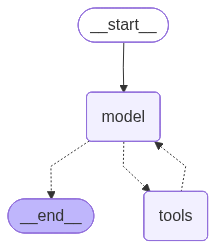

In [26]:
from langchain.agents import create_agent

agent = create_agent(
    model = groq,
    tools = [calculator, tavily_tool],
    system_prompt = "You are a helpful assistant."
)
agent

In [30]:
user_input = """
Explain in detail the impact of the Middle East war on markets.
List multiple key points and include detailed insights.
Also calculate 12 * 13.
"""

for step in agent.stream(
    {"messages":[
        {"role":"user","content":user_input}
    ]},
    stream_mode="values"
):
    msg = step["messages"][-1]
    print(msg.content)


Explain in detail the impact of the Middle East war on markets.
List multiple key points and include detailed insights.
Also calculate 12 * 13.


{"query": "Middle East war impact on markets", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://finance.yahoo.com/news/economists-gauge-hit-mideast-war-035021738.html", "title": "Economists Gauge Hit From Mideast War as China Seen Among ...", "content": "The most immediate impact from the escalating Middle East conflict is through market reaction as investors take flight to safe havens such as gold, while stocks", "score": 0.7482976, "raw_content": null}, {"url": "https://www.wsj.com/finance/stocks/middle-east-conflict-circles-the-worlds-markets-stirring-fears-of-stalled-growth-inflation-2400b2d8?gaa_at=eafs&gaa_n=AWEtsqc0RatPJpQy76-f8CuHZuhvZ6v8pNSC8PWzLdPyPYuF5-tNvGmUVvul&gaa_ts=69becef6&gaa_sig=NMyzj17g7uywazr-y6Lb6FkK5WvJkmMyta9FP0vte0Yky3crqeJK6WzW-FGSlHX4BFb3MNCO7AD1xJs7H2wh1g%3D%3D", "title": "Mi

In [31]:
agent.invoke(
    {"messages":[
        {"role":"user","content":user_input}
    ]}
)

{'messages': [HumanMessage(content='\nExplain in detail the impact of the Middle East war on markets.\nList multiple key points and include detailed insights.\nAlso calculate 12 * 13.\n', additional_kwargs={}, response_metadata={}, id='b3b4e9dd-8e0a-4fdd-9dc2-89716f6bf195'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'ttqbnxta4', 'function': {'arguments': '{"end_date":"2022-12-31","include_domains":["reuters.com","bloomberg.com"],"include_images":true,"query":"Middle East war impact on markets","search_depth":"advanced","start_date":"2022-01-01","time_range":"month","topic":"finance"}', 'name': 'tavily_search'}, 'type': 'function'}, {'id': 'qhqrv8bjz', 'function': {'arguments': '{"expression":"12 * 13"}', 'name': 'Calculator'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 781, 'prompt_tokens': 1792, 'total_tokens': 2573, 'completion_time': 1.602582156, 'completion_tokens_details': None, 'prompt_time': 0.133574997, 'prompt_tokens_d